# Information
This notebook defines the necessary preprocessing steps to prepare the player_stats dataset for model training. A subset of these steps will later be exported into a standalone Python module and integrated into the data loading and preprocessing pipeline used for inference. These reusable steps are explicitly labeled throughout the notebook.

The remaining steps are specific to the data integration process and are required to merge data from Transfermarkt (TM) with data from Sofascore. This integration is necessary to link player_stats with the corresponding player ratings (grades) and is not part of the final preprocessing pipeline used during model deployment.

In [79]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/transform/pro/stats_with_rating.csv")

In [80]:
cols = ["player_id", "match_id", "club_id", "player_name", "date"]
df = df.drop(columns = cols, errors="ignore")

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = ["goals", "assists", "minutes", "team_goals", "team_conceded"]
cat_cols = ["position"]
bool_cols = ["yellow", "red", "start_eleven"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bool", "passthrough", bool_cols),
    ]
)


In [87]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split

X = df.drop(columns=["rating"])
y = df["rating"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bool", "passthrough", bool_cols),
    ]
)


# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # reproduzierbar
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.3160545471363984
RMSE: 0.4332689326419666


In [89]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

# -------------------
# Data Split
# -------------------
X = df.drop(columns=["rating"])
y = df["rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------
# Pipeline
# -------------------
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# -------------------
# GridSearch
# -------------------
param_grid = {
    "model__n_estimators": [50, 100, 200, 400, 1000],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

# -------------------
# Best Model Evaluation
# -------------------
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("Best Params:", grid.best_params_)
print("MAE:", mae)
print("RMSE:", rmse)


Fitting 5 folds for each of 80 candidates, totalling 400 fits


KeyboardInterrupt: 

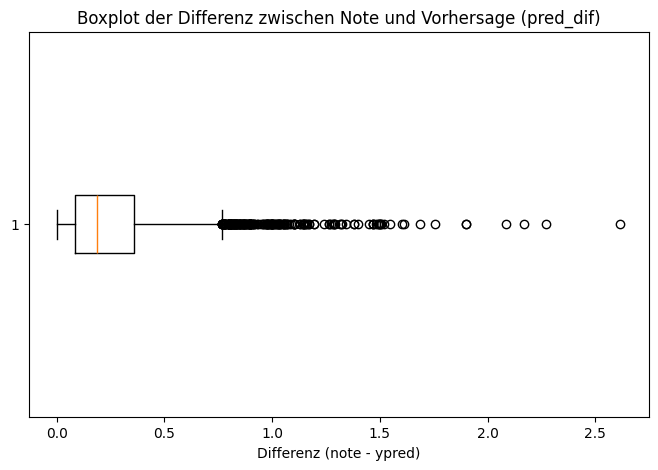

In [85]:
# Bestes Modell verwenden und DataFrame mit Vorhersagen erstellen
# Annahme: best_model, X_test, y_test existieren bereits (aus GridSearchCV)

# Vorhersagen mit dem besten Modell
y_pred = best_model.predict(X_test)

# Neues DataFrame: Kopie von X_test
results_df = X_test.copy()
results_df["note"] = y_test.values  # Echte Noten
results_df["ypred"] = y_pred        # Vorhersagen
results_df["pred_dif"] = abs(results_df["note"] - results_df["ypred"])  # Differenz

results_df.head()

# Boxplot der Differenzen
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.boxplot(results_df["pred_dif"], vert=False)
plt.title("Boxplot der Differenz zwischen Note und Vorhersage (pred_dif)")
plt.xlabel("Differenz (note - ypred)")
plt.show()